## Noise Tutorial

Another common constraint of observations is noise. Noise limits and distorts the information/statistics of an observation and thus, it is useful to test spectral methodologies under the influence of noise.

We first import the usual, and generate a 2D field.

Set statistic function calculation flags: (<CalculationMode.USE_GPU: 1>,)


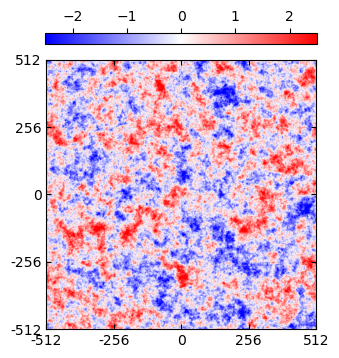

In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import sys
import os
sys.path.insert(0, os.path.abspath('../../../'))
# Utility to make plots look nice
from kea.utils.plotting import modify_latex_rc, make_ax_step, pretty_axes
from kea.utils import binning
# modify_latex_rc()
# modify_latex_rc()

# Use the GPU for computing the SF, ACF, and performing Gaussian convolutions
from kea.utils import set_calculation_mode
set_calculation_mode(use_cpu=False, use_gpu=True)

from kea.simulator import make_field

# Set number of grid points
N = 1024
# Number of dimensions (two-dimensional)
D = 2
# We have the same number of grid points in each dimension
grid_dims = (N,N)

# Make the field
field = make_field(grid_dims,
                   spectrum_kwargs={'powerlaw': -8./3., 'cutoff_scale': 5.},
                   spectrum_function='cutoff_powerlaw',
                   seed=1, normalize_output=True)

fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5))
im = ax.imshow(field, cmap='bwr', vmin=-2.5, vmax=2.5, origin='lower')
pretty_axes(ax)
ax.set_xticks(*make_ax_step(N, N//4))
ax.set_yticks(*make_ax_step(N, N//4))
cbar_ax = fig.add_axes([0.125, 0.925, 0.775, 0.03])
fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar_ax.xaxis.set_ticks_position('top')

**kea** supplies 2 noise helper routines: *applying* Poisson noise, and adding Gaussian noise.

In [2]:
from kea.simulator import apply_poisson, apply_gaussian

Add Gaussian noise and see the results:

0.0007389213125281787


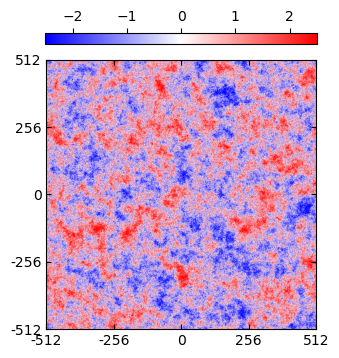

In [9]:
## Add Gaussian noise on each pixel with standard deviation of 1
noisy_field = apply_gaussian(field, 1.)
## Plot noisy field
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5))
im = ax.imshow(noisy_field, cmap='bwr', vmin=-2.5, vmax=2.5, origin='lower')
pretty_axes(ax)
ax.set_xticks(*make_ax_step(N, N//4))
ax.set_yticks(*make_ax_step(N, N//4))
cbar_ax = fig.add_axes([0.125, 0.925, 0.775, 0.03])
fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar_ax.xaxis.set_ticks_position('top')

The Gaussian noise acts as a constant-in-wavenumber noise floor that dominates at small wavenumber.

/home/mark/miniconda3/envs/astro/lib/python3.13/site-packages/scipy/stats/_binned_statistic.py:694: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))
/home/mark/miniconda3/envs/astro/lib/python3.13/site-packages/scipy/stats/_binned_statistic.py:694: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))


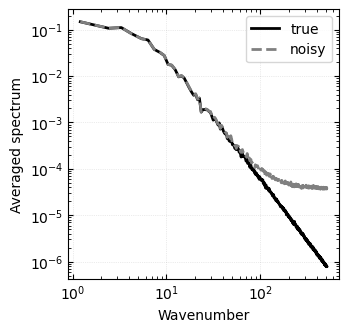

In [12]:
from kea.statistics.spectra import fourier_modal_spectrum, bin_spectrum
kvec, modal_spectrum = fourier_modal_spectrum(field)
kp, fekp, p_widths = bin_spectrum(kvec, modal_spectrum, 'averaged')

kvec_noisy, modal_spectrum_noisy = fourier_modal_spectrum(noisy_field)
kp_noisy, fekp_noisy, _ = bin_spectrum(kvec_noisy, modal_spectrum_noisy, 'averaged')

## Plot spectra
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5))
ax.plot(kp, fekp, linewidth=2., linestyle='-', color='black', label='true')
ax.plot(kp_noisy, fekp_noisy, linewidth=2., linestyle='--', color='gray', label='noisy')
ax.loglog()
pretty_axes(ax)
ax.set_ylabel('Averaged spectrum')
ax.set_xlabel('Wavenumber')
ax.legend()

Some spectral estimates support cross-spectra. If you have 1 field with 2 realizations of noise, you can estimate the cross-spectrum -- the noise is typically not correlation and thus is removed.

/home/mark/miniconda3/envs/astro/lib/python3.13/site-packages/scipy/stats/_binned_statistic.py:694: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))
/home/mark/miniconda3/envs/astro/lib/python3.13/site-packages/scipy/stats/_binned_statistic.py:694: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))


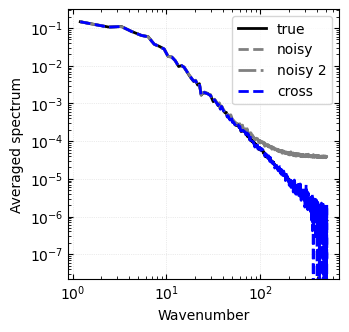

In [14]:
## Add Gaussian noise on each pixel with standard deviation of 1
noisy_field2 = apply_gaussian(field, 1.)
## Compute spectrum of second noisy field
kvec_noisy2, modal_spectrum_noisy2 = fourier_modal_spectrum(noisy_field2)
kp_noisy2, fekp_noisy2, _ = bin_spectrum(kvec_noisy2, modal_spectrum_noisy2, 'averaged')
## Compute cross-spectrum
kvec_x, modal_spectrum_x = fourier_modal_spectrum(noisy_field, noisy_field2)
kp_x, fekp_x, _ = bin_spectrum(kvec_x, modal_spectrum_x, 'averaged')

## Plot them all
## Plot spectra
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5))
ax.plot(kp, fekp, linewidth=2., linestyle='-', color='black', label='true')
ax.plot(kp_noisy, fekp_noisy, linewidth=2., linestyle='--', color='gray', label='noisy')
ax.plot(kp_noisy2, fekp_noisy2, linewidth=2., linestyle='-.', color='gray', label='noisy 2')
ax.plot(kp_x, fekp_x, linewidth=2., linestyle=':', color='blue', label='cross')
ax.loglog()
pretty_axes(ax)
ax.set_ylabel('Averaged spectrum')
ax.set_xlabel('Wavenumber')
ax.legend()